In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import *
from imblearn.metrics import specificity_score
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyRegressor, LazyClassifier
from scipy.stats import randint, uniform, zscore, stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error, accuracy_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import TargetEncoder
from sklearn import linear_model
from sklearn.linear_model import Lasso, LogisticRegression, LinearRegression
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.compose import ColumnTransformer
import joblib

In [2]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')
pd.set_option('display.max_columns',None)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [3]:
var_cero = ['Glucose','BloodPressure','BMI','Insulin']
df[var_cero] == 0
df[var_cero] = df[var_cero].replace(0,np.nan)

Train Test Split

In [4]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
imputer = MissForest()

X_train_imp = imputer.fit_transform(X_train)
X_train_imp

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 89.94it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
60,2,0,0.30,21,84.00,28.24,69.85,111.18
618,9,24,1.28,50,112.00,28.20,82.00,169.58
346,1,19,0.65,22,139.00,28.70,46.00,83.00
294,0,0,0.25,65,161.00,21.90,50.00,240.72
231,6,37,0.24,46,134.00,46.20,80.00,370.00
...,...,...,...,...,...,...,...,...
71,5,35,0.41,26,139.00,28.60,64.00,140.00
106,1,0,0.21,27,96.00,22.40,122.00,98.70
270,10,37,1.14,38,101.00,45.60,86.00,119.07
435,0,0,0.20,29,141.00,42.40,73.71,117.73


In [7]:
X_test_imp = imputer.transform(X_test)
X_test_imp

 60%|██████    | 3/5 [00:00<00:00, 94.46it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
668,6,33,0.43,43,98.00,34.00,58.00,190.00
324,2,32,0.15,21,112.00,35.70,75.00,168.19
624,2,0,0.16,21,108.00,30.80,64.00,145.49
690,8,0,0.86,34,107.00,24.60,80.00,140.03
473,7,0,0.21,50,136.00,29.90,90.00,142.22
...,...,...,...,...,...,...,...,...
355,9,0,0.30,49,165.00,30.40,88.00,116.72
534,1,30,1.25,24,77.00,33.30,56.00,56.00
344,8,0,0.48,57,95.00,36.80,72.00,142.68
296,2,38,0.34,29,146.00,28.00,70.00,360.00


Feature Importance

In [8]:
#Metodo1

model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1).fit(X_train_imp,y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

#Convertir a dataframe
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

#importancia acumulada
df_rf_imp['rf_importance_accum'] = df_rf_imp['rf_importance'].cumsum()

df_rf_imp


,feature,rf_importance,rf_importance_accum
4,Insulin,22.42,22.42
7,Age,15.93,38.35
5,BMI,15.18,53.53
3,SkinThickness,13.51,67.04
2,BloodPressure,11.03,78.06
6,DiabetesPedigreeFunction,7.78,85.85
0,Pregnancies,7.26,93.11
1,Glucose,6.89,100.00


In [42]:
#METODO 2
#XGBClassifier

#crear conjunto de val
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp,y_train, test_size=0.2,random_state=42)

#ajustar modelo

model_xgb = XGBClassifier(objective='binary:logistic',random_state=42).fit(X_train1,y_train1)

#10 permutaciones por caract

perm = permutation_importance(model_xgb,X_val,y_val,n_repeats=10,random_state=42,n_jobs=-1,scoring='recall')
df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
4,Insulin,16.67
5,BMI,5.00
3,SkinThickness,4.76
0,Pregnancies,3.10
1,Glucose,2.38
7,Age,1.90
2,BloodPressure,1.19
6,DiabetesPedigreeFunction,0.48


In [43]:
#metodo3: Shap

#METODO 3: usar SHAP

model_lgbm = lgb.LGBMClassifier(random_state=42,n_jobs=-1).fit(X_train1,y_train1)

explainer = shap.Explainer(model_lgbm,X_val)
shap_vals = explainer(X_val,check_additivity=False).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
4,Glucose,25.72
3,Age,16.64
5,BMI,15.43
7,Insulin,12.48
2,DiabetesPedigreeFunction,11.16
6,BloodPressure,8.77
1,SkinThickness,5.54
0,Pregnancies,4.26


In [44]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,16.67,12.48
0,Age,15.93,38.35,1.90,16.64
1,BMI,15.18,53.53,5.00,15.43
7,SkinThickness,13.51,67.04,4.76,5.54
2,BloodPressure,11.03,78.06,1.19,8.77
3,DiabetesPedigreeFunction,7.78,85.85,0.48,11.16
6,Pregnancies,7.26,93.11,3.10,4.26
4,Glucose,6.89,100.00,2.38,25.72


In [45]:
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm_imp']>=1)&(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,16.67,12.48
0,Age,15.93,38.35,1.90,16.64
1,BMI,15.18,53.53,5.00,15.43
7,SkinThickness,13.51,67.04,4.76,5.54
2,BloodPressure,11.03,78.06,1.19,8.77
6,Pregnancies,7.26,93.11,3.10,4.26
4,Glucose,6.89,100.00,2.38,25.72


In [46]:
features = df_filt['feature']
features

5          Insulin
0              Age
1              BMI
7    SkinThickness
2    BloodPressure
6      Pregnancies
4          Glucose
Name: feature, dtype: object

Modelado

In [47]:
X_train_sel = X_train_imp[features]
X_test_sel = X_test_imp[features]

In [101]:
#v1 simple

random_f_1 = RandomForestClassifier(n_estimators=4,max_depth=2,min_samples_leaf=15,random_state=42)
random_f_1.fit(X_train_sel,y_train)



,n_estimators,4
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
#V1: evaluacion del modelo en entrenamiento y prueba
train_pred = random_f_1.predict(X_train_sel)
test_pred= random_f_1.predict(X_test_sel)

In [20]:
def get_metrics(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_auc = train_auc - test_auc
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy, train_f1, train_auc, train_precision, train_recall, train_specificity],[test_accuracy, test_f1, test_auc, test_precision, test_recall, test_specificity],[diff_accuracy, diff_f1, diff_auc, diff_precision, diff_recall, diff_specificity]],
                              columns = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall', 'Specificity'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

In [79]:
#v2 complejo
random_f_2 = RandomForestClassifier(n_estimators=100,max_depth=20,min_samples_leaf=1,random_state=42)
random_f_2.fit(X_train_sel,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
#V2: evaluacion del modelo en entrenamiento y prueba
train_pred2 = random_f_2.predict(X_train_sel)
test_pred2= random_f_2.predict(X_test_sel)

In [103]:
#V1
get_metrics(y_train,y_test,train_pred,test_pred)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,0.76,0.55,0.68,0.76,0.44,0.93
Test,0.79,0.66,0.74,0.79,0.56,0.92
Diferencia,-0.04,-0.11,-0.06,-0.04,-0.13,0.01


In [61]:
#V2
get_metrics(y_train,y_test,train_pred2,test_pred2)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,1.00,1.00,1.00,1.00,1.00,1.00
Test,0.73,0.62,0.71,0.61,0.64,0.78
Diferencia,0.27,0.38,0.29,0.39,0.36,0.22



En este proyecto se entrenaron dos versiones de RandomForest. Uno simple y otro complejo. El modelo simple obtuvo un mejor resultado en accuracy (79%) que el complejo, que obtuvo el mismo resultado que el DecissionTree optimizado. 

En este caso, la métrica que buscábamos optimizar era el Accuracy, es decir, el porcentaje de predicciones totales que el modelo realizó correctamente. Como se observa en las matrices de confusión, el modelo 1 (simple) logró medir correctamente 122 resultados de 154. Mientras que el modelo 2 (Complejo) solo lo logro con 112 de 154. 

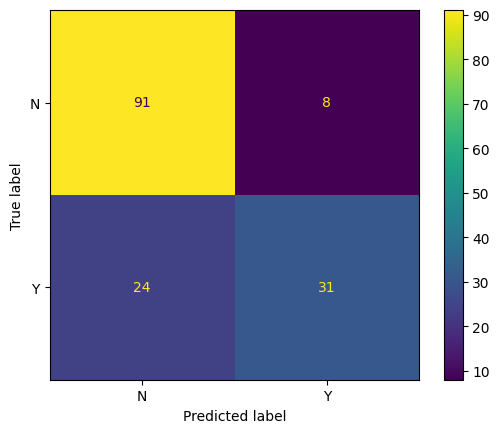

In [ ]:
#Matriz 1
cm = confusion_matrix(y_test, test_pred)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

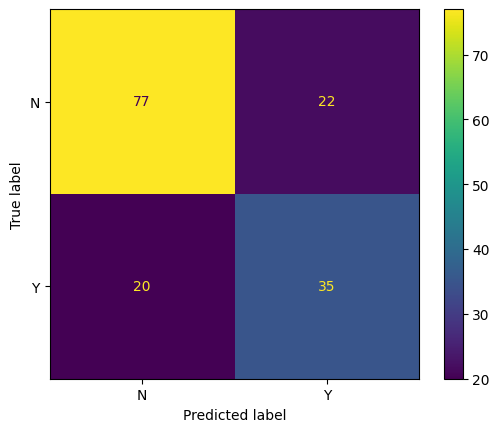

In [106]:
#Matriz 2
cm = confusion_matrix(y_test, test_pred2)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

In [107]:
joblib.dump(random_f_1,'random_forest_diabletes.pkl')

['random_forest_diabletes.pkl']